# Data Science Job Market Analysis

**Name:** [Your Name]  
**Date:** [Current Date]  
**Dataset:** Data Science Job Market Trends


## Project Overview
This notebook provides a comprehensive analysis of data science job market trends, skill requirements, and career pathways using data-driven approaches. The analysis focuses on identifying key skills, emerging trends, and personalized recommendations for career development.

## 1. Initial Setup and Configuration

### 1.1 Import Required Libraries
Import all necessary packages and configure the environment for analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 
import warnings
from tqdm.auto import tqdm
import sys
warnings.filterwarnings('ignore')

import plotly.io as pio

# Set up notebook display
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style("whitegrid")
%matplotlib inline
pio.renderers.default = 'notebook'  # For Plotly in notebook

# Set up plotting style
plt.style.use('default')
sns.set_palette("viridis")

In [2]:
sys.path.append('..')
from src.analyze_jobs import DataScienceJobsAnalyzer

# Initialize the analyzer
analyzer = DataScienceJobsAnalyzer(data_dir="../data")

### 1.2 Load and Prepare Data
Load the pre-processed dataset containing job market information.

In [3]:
# Load and clean the data
df = analyzer.load_cleaned_data()

df.info()


INFO:src.analyze_jobs:✅ Loaded 18088 cleaned records


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18088 entries, 0 to 18087
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   country                 18088 non-null  object 
 1   company                 18088 non-null  object 
 2   cleaned_title_category  18088 non-null  object 
 3   seniority_level         18088 non-null  object 
 4   skills                  18088 non-null  object 
 5   date                    18088 non-null  object 
 6   salary_category         18088 non-null  object 
 7   avg_salary_usd          6978 non-null   float64
 8   job_type                18088 non-null  object 
 9   work_mode               18088 non-null  object 
 10  skills_count            18088 non-null  int64  
dtypes: float64(1), int64(1), object(9)
memory usage: 1.5+ MB


In [4]:
pivot_df = analyzer.create_skill_pivot(df)

print(f"✅ Successfully loaded {len(df):,} job records")
print(f"📊 Created skill pivot with {len(pivot_df):,} skill mentions")
print(f"🎯 Analyzing {pivot_df['skill'].nunique():,} unique skills")

# Display basic dataset info
print("\n📈 Dataset Overview:")
print(f"   • Time period: {pivot_df['date'].min()} to {pivot_df['date'].max()}")
print(f"   • Countries: {pivot_df['country'].nunique()}")
print(f"   • Companies: {pivot_df['company'].nunique()}")
print(f"   • Job roles: {pivot_df['cleaned_title_category'].nunique()}")
print(f"   • Seniority levels: {pivot_df['seniority_level'].nunique()}")



✅ Successfully loaded 18,088 job records
📊 Created skill pivot with 221,951 skill mentions
🎯 Analyzing 327 unique skills

📈 Dataset Overview:
   • Time period: 2023.0_10.0 to 2025.0_9.0
   • Countries: 115
   • Companies: 2418
   • Job roles: 12
   • Seniority levels: 8


## 2. Market Overview Analysis
### 2.1 Overall Skill Frequency Analysis

🏆 TOP 5 MOST IN-DEMAND SKILLS


<Figure size 1400x800 with 0 Axes>

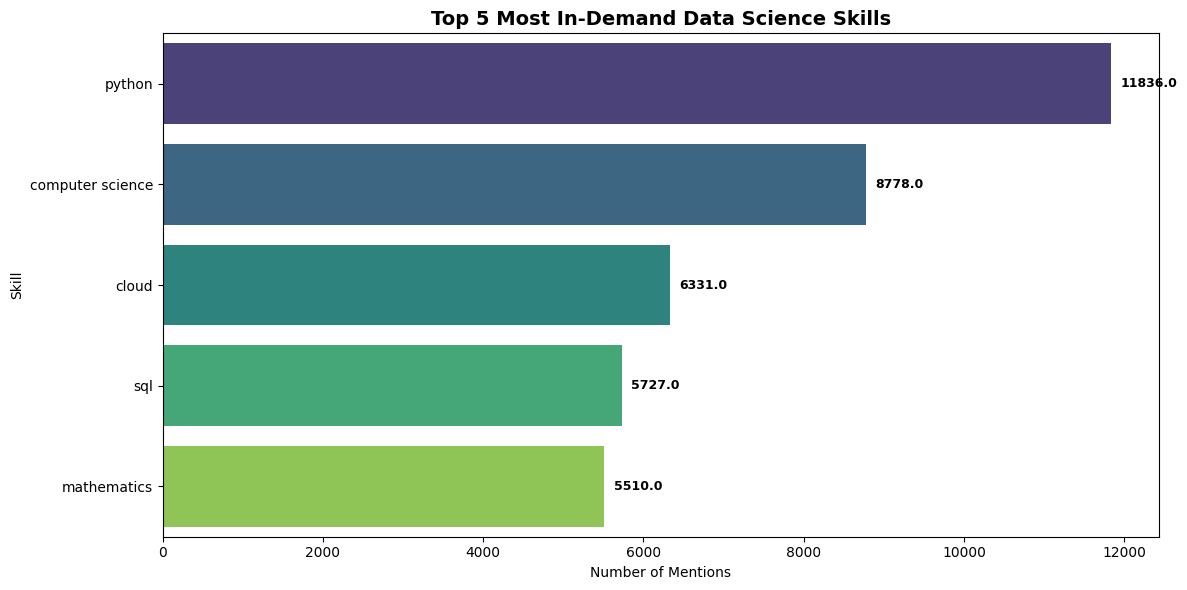

,skill,mentions,prevalence,total_jobs
0,python,"11,836",65.6%,18029
1,computer science,"8,778",48.7%,18029
2,cloud,"6,331",35.1%,18029
3,sql,"5,727",31.8%,18029
4,mathematics,"5,510",30.6%,18029


In [5]:
# Analyze top skills across the entire market
top_skills = analyzer.analyze_skill_frequency(pivot_df, top_n=5)

print("🏆 TOP 5 MOST IN-DEMAND SKILLS")
print("="*50)

plt.figure(figsize=(14, 8))
analyzer.plot_skills_bar(top_skills, column='skill', top_n=5, 
                        title='Top 5 Most In-Demand Data Science Skills')

# Display detailed table
display(top_skills.head(5).style.background_gradient(cmap='Blues', subset=['prevalence'])
       .format({'prevalence': '{:.1f}%', 'mentions': '{:,}'})
       .set_caption('Top 5 Skills by Prevalence'))

## 3. Seniority-Level Analysis
### 3.1 Skills by Seniority Level

👨‍💼 SKILL DISTRIBUTION BY SENIORITY LEVEL


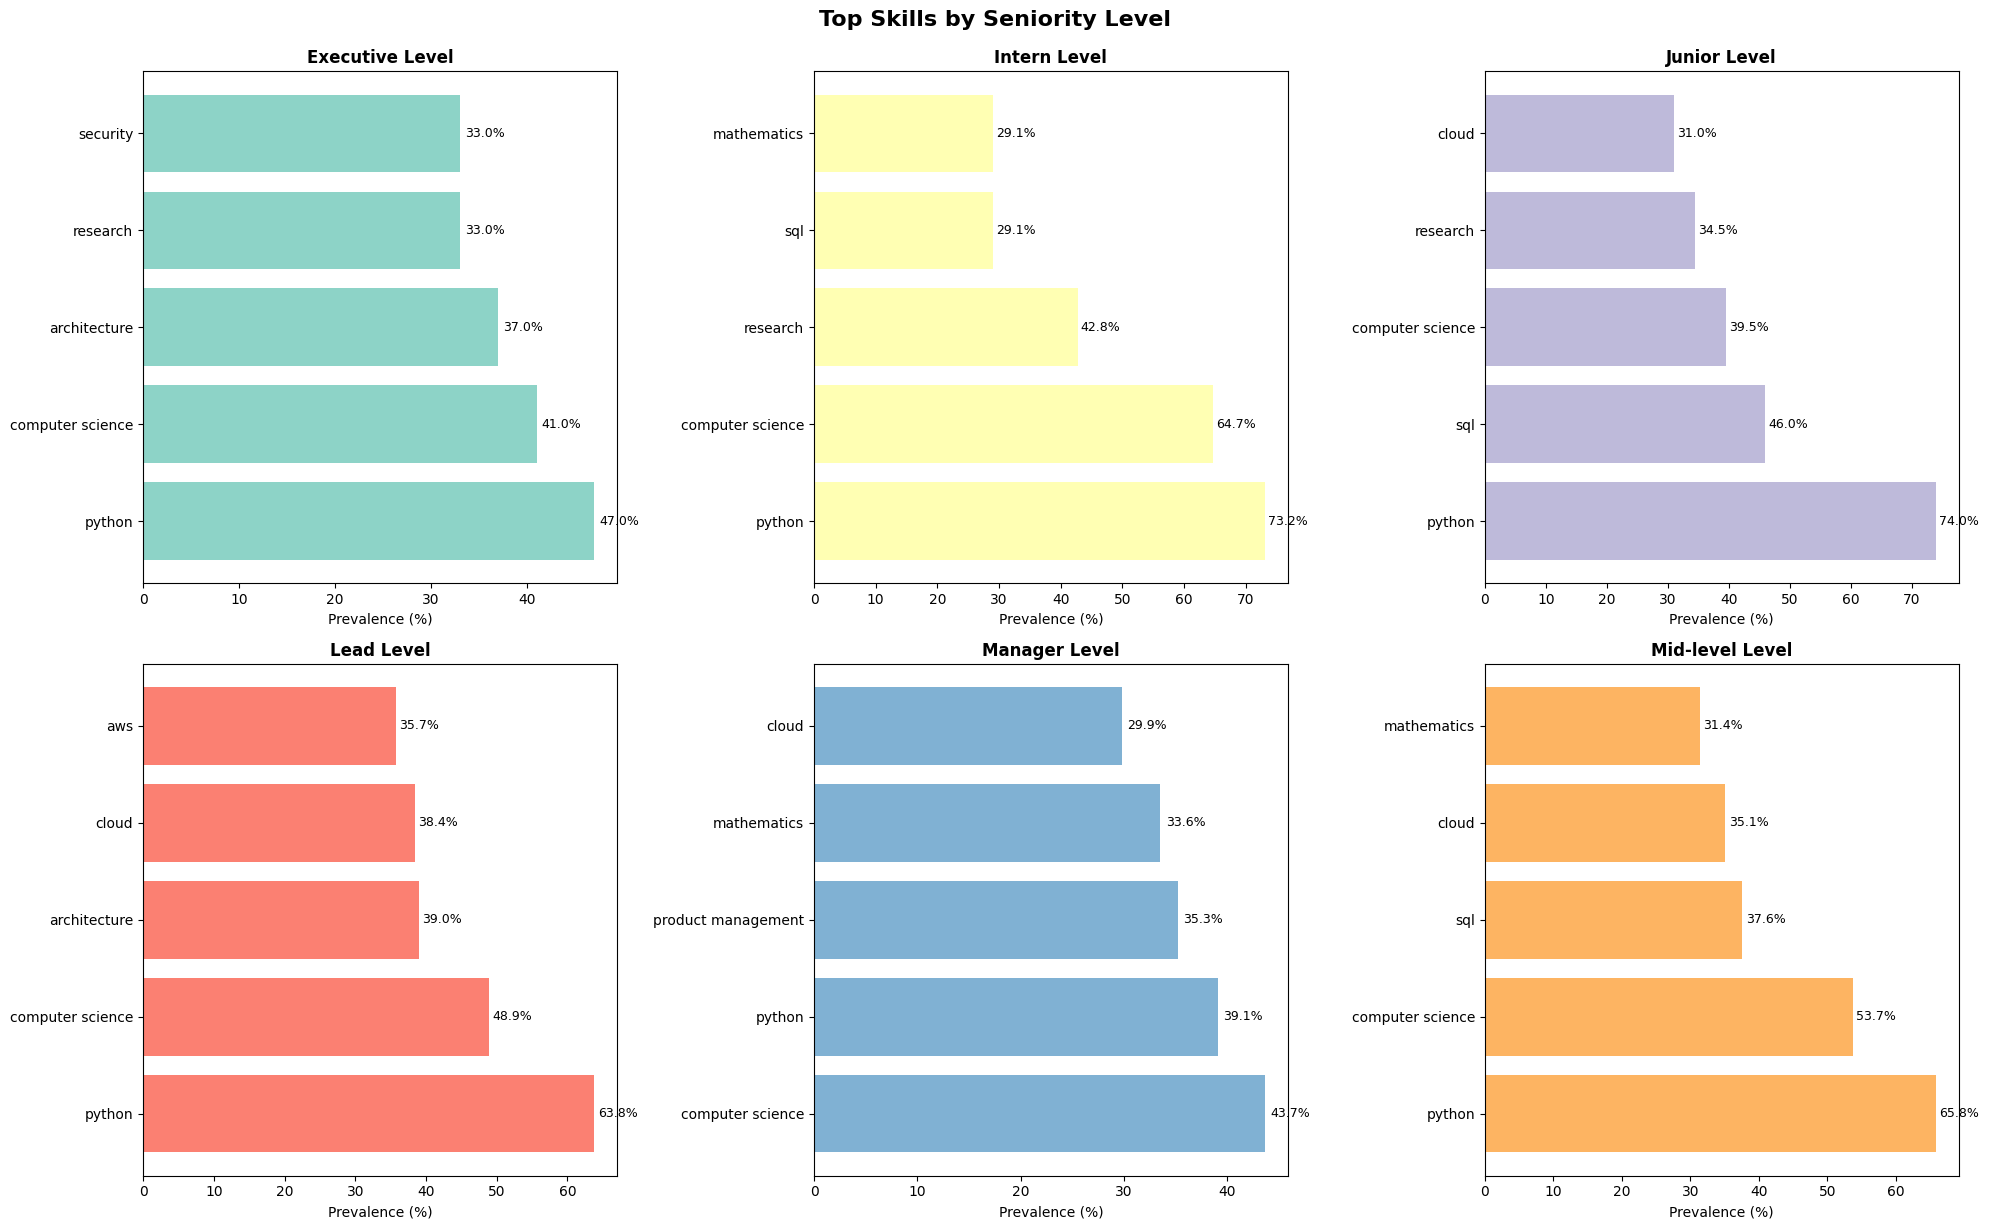

In [6]:
# Analyze skills across different seniority levels
seniority_skills = analyzer.analyze_skills_by_seniority(pivot_df, top_n=5)

print("👨‍💼 SKILL DISTRIBUTION BY SENIORITY LEVEL")
print("="*55)

# Create visualization for each seniority level
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for idx, (level, skills_df) in enumerate(seniority_skills.items()):
    if idx < 6:  # Limit to first 6 seniority levels
        ax = axes[idx]
        top_skills = skills_df.head(5)
        
        ax.barh(top_skills['skill'], top_skills['prevalence'], color=analyzer.colors[idx])
        ax.set_title(f'{level} Level', fontweight='bold', fontsize=12)
        ax.set_xlabel('Prevalence (%)')
        
        # Add value labels
        for i, v in enumerate(top_skills['prevalence']):
            ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.suptitle('Top Skills by Seniority Level', fontsize=16, fontweight='bold', y=1.02)
plt.show()

### 3.2 Seniority-Specific Skill Patterns

🎯 ANALYZING SENIORITY-SPECIFIC SKILL PATTERNS


INFO:src.analyze_jobs:🎯 Identifying seniority-specific skill patterns...
Analyzing seniority patterns: 100%|██████████| 6/6 [00:01<00:00,  3.11it/s]
INFO:src.analyze_jobs:
INFO:src.analyze_jobs:🎯 SENIORITY-SPECIFIC SKILL PATTERNS INSIGHTS
INFO:src.analyze_jobs:======================================================================
INFO:src.analyze_jobs:
📋 JUNIOR LEVEL:
INFO:src.analyze_jobs:   • Total jobs: 200
INFO:src.analyze_jobs:   • Unique skills: 205
INFO:src.analyze_jobs:   • Skill concentration: 0.306
INFO:src.analyze_jobs:   • Top skills: python (74.0%), sql (46.0%), computer science (39.5%)
INFO:src.analyze_jobs:   • Level-specific: No strongly specific skills identified
INFO:src.analyze_jobs:
📋 MID-LEVEL LEVEL:
INFO:src.analyze_jobs:   • Total jobs: 322
INFO:src.analyze_jobs:   • Unique skills: 223
INFO:src.analyze_jobs:   • Skill concentration: 0.309
INFO:src.analyze_jobs:   • Top skills: python (65.8%), computer science (53.7%), sql (37.6%)
INFO:src.analyze_jobs:   • Level-

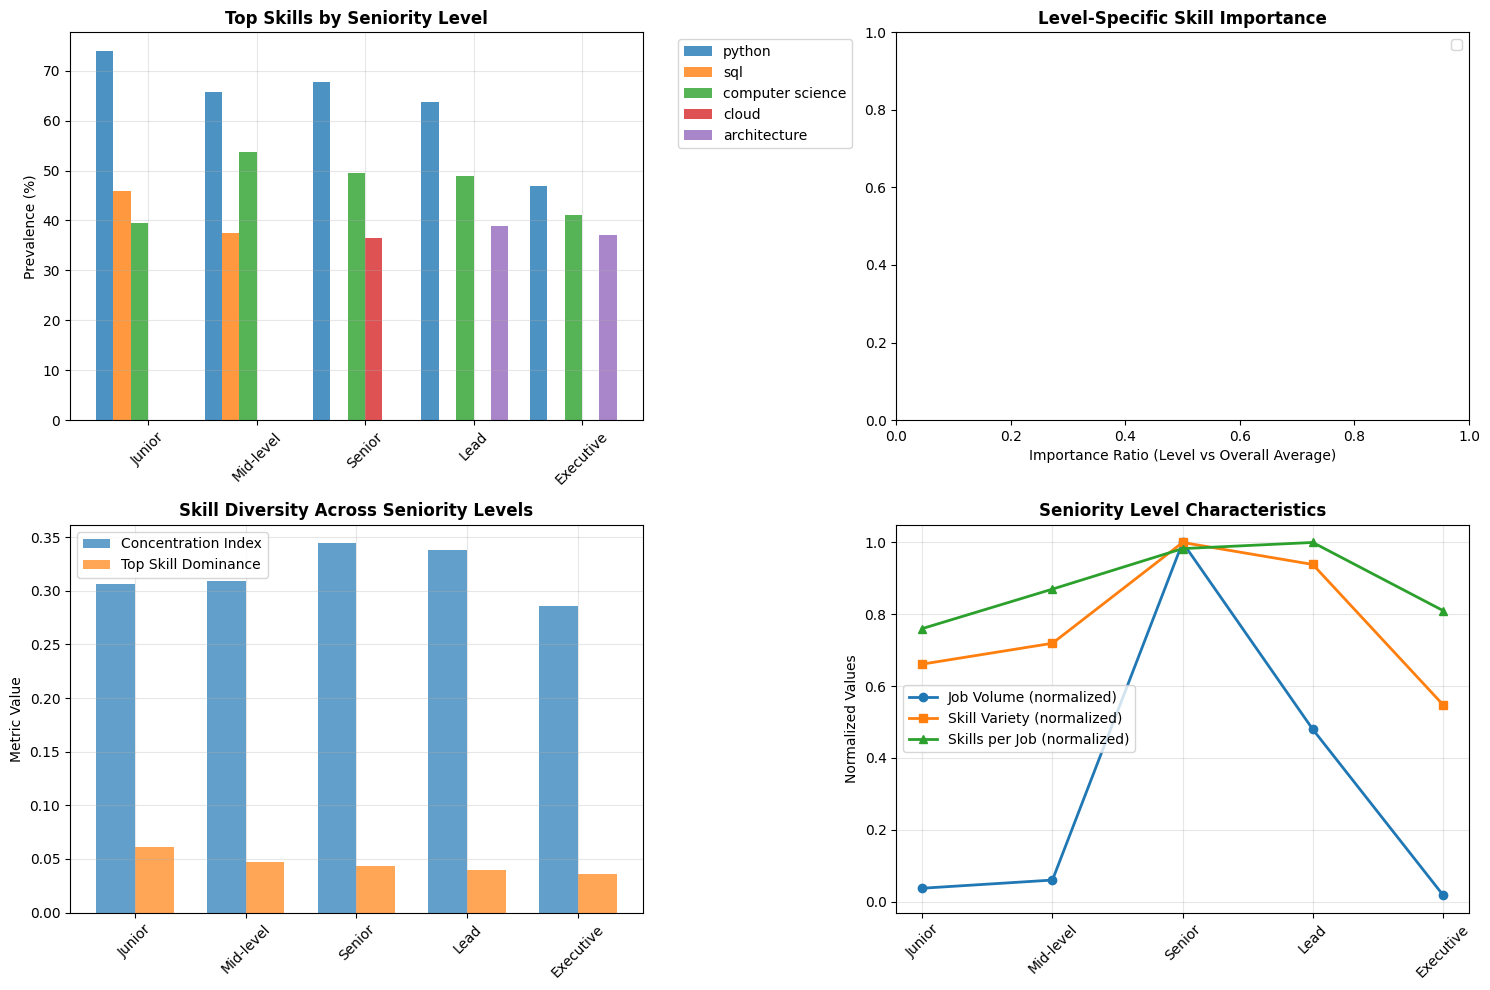

In [7]:
# Identify seniority-specific patterns
print("🎯 ANALYZING SENIORITY-SPECIFIC SKILL PATTERNS")
print("="*55)

# Get progression data for key skills
key_skills = ['Python', 'SQL', 'Machine Learning', 'AWS', 'Tableau', 'Spark']
progression_data = analyzer.analyze_skill_progression_data(pivot_df, key_skills)

# Analyze patterns
seniority_patterns = analyzer.analyze_seniority_specific_patterns(pivot_df, progression_data)

# Create visualization
analyzer.plot_seniority_patterns(seniority_patterns)

### 3.3 Skill Progression Across Career Levels

In [8]:
print("📈 SKILL PROGRESSION ACROSS CAREER LEVELS")
print("="*50)

# Plot organized progression view
analyzer.plot_skill_progression_organized(progression_data)

# Additional simple view for key technical skills
technical_skills = ['Python', 'Machine Learning', 'Spark', 'AWS', 'TensorFlow', 'Kubernetes']
tech_progression = analyzer.analyze_skill_progression_data(pivot_df, technical_skills)

print("\n🔧 Technical Skill Progression:")
analyzer.plot_skill_progression_simple(tech_progression, technical_skills)

📈 SKILL PROGRESSION ACROSS CAREER LEVELS

🔧 Technical Skill Progression:


## 4. Role-Based Analysis
### 4.1 Skills by Job Role 

🎭 SKILL PROFILES BY JOB ROLE


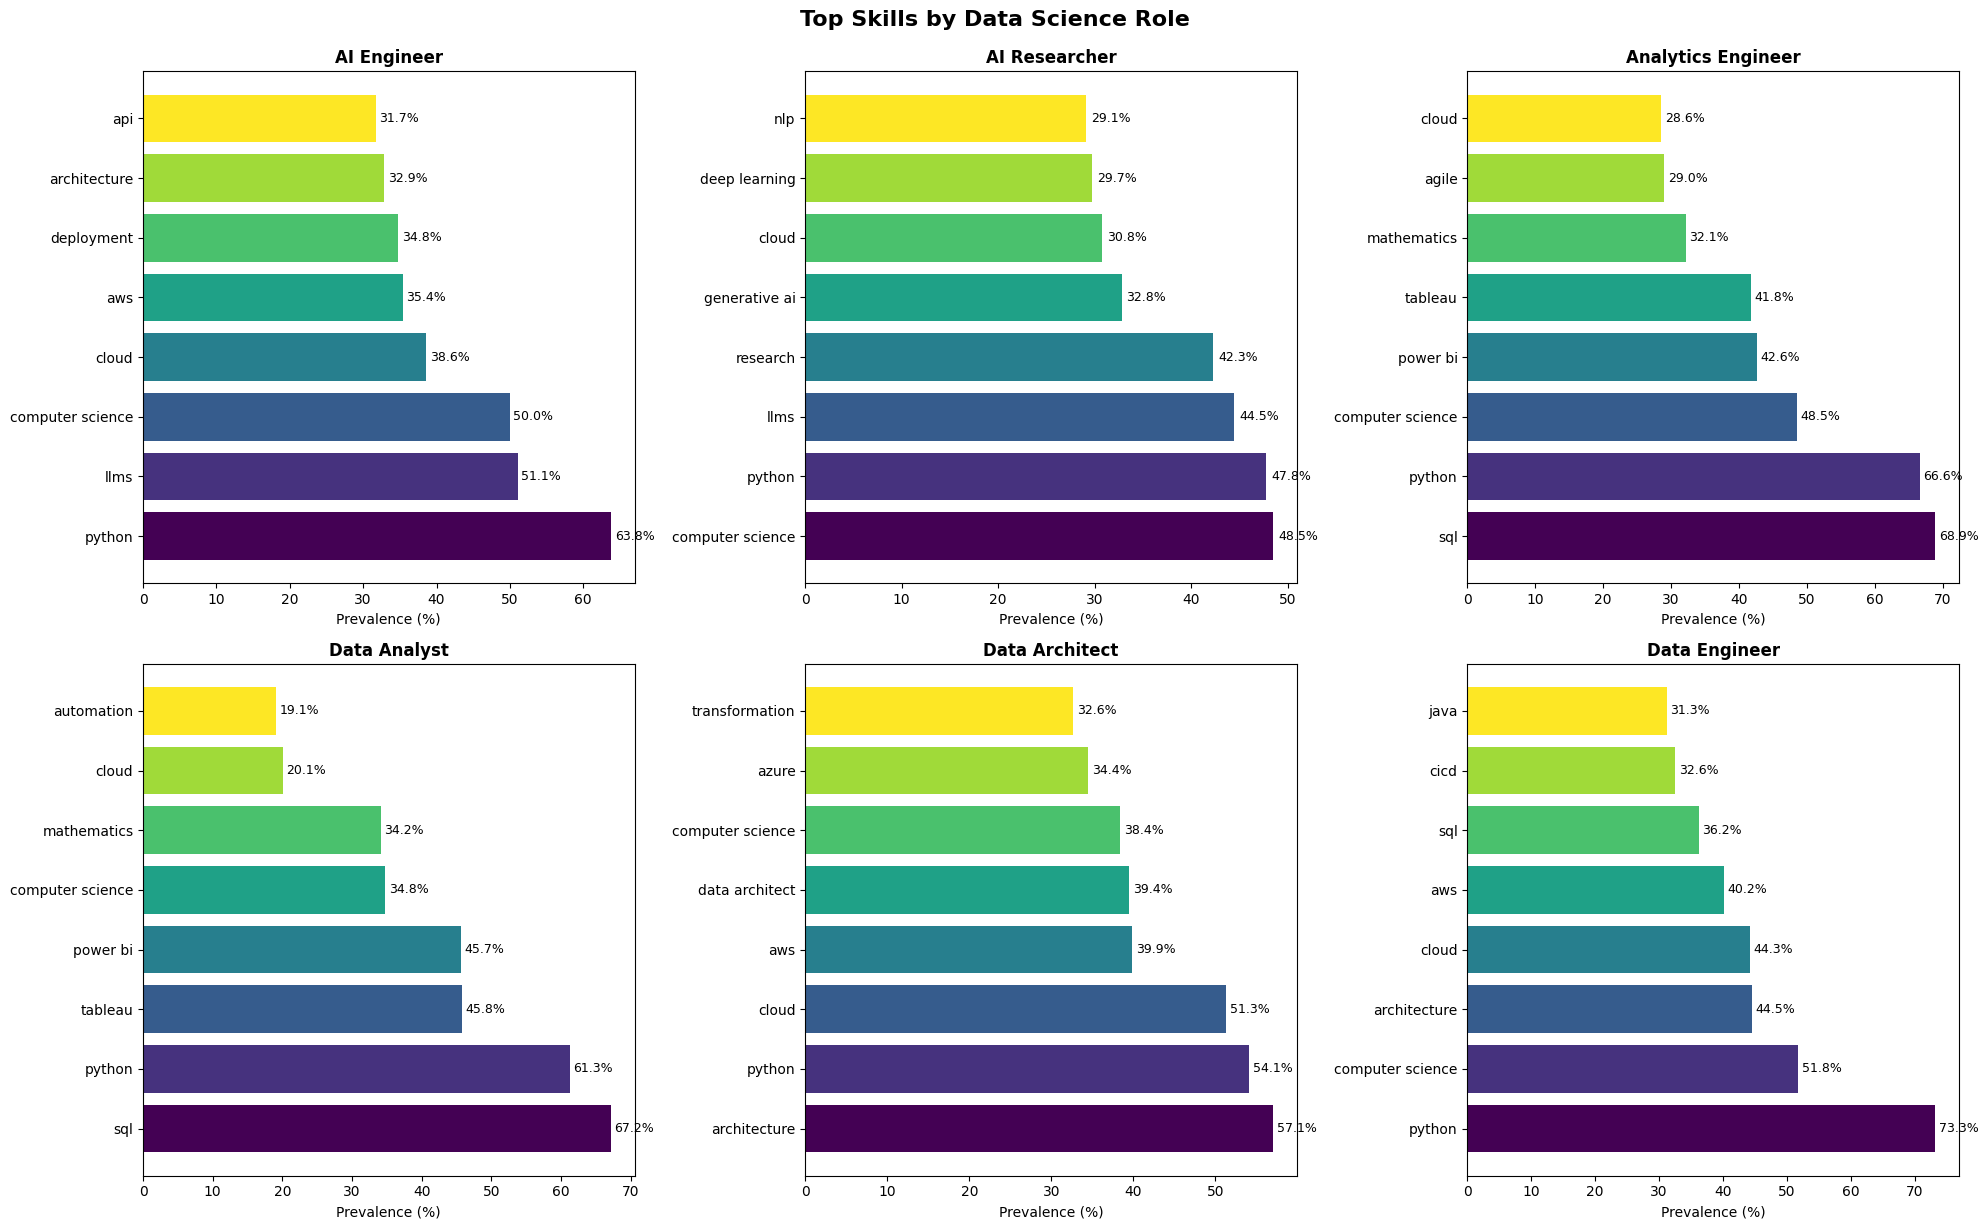

In [9]:
# Analyze skills for different data roles
role_skills = analyzer.analyze_skills_by_role(pivot_df, top_n=12)

print("🎭 SKILL PROFILES BY JOB ROLE")
print("="*40)

# Visualize top roles
top_roles = list(role_skills.keys())[:6]  # Show first 6 roles

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for idx, role in enumerate(top_roles):
    if idx < 6:
        ax = axes[idx]
        role_data = role_skills[role].head(8)
        
        colors = plt.cm.viridis(np.linspace(0, 1, len(role_data)))
        ax.barh(role_data['skill'], role_data['prevalence'], color=colors)
        ax.set_title(f'{role}', fontweight='bold', fontsize=12)
        ax.set_xlabel('Prevalence (%)')
        
        # Add value labels
        for i, v in enumerate(role_data['prevalence']):
            ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.suptitle('Top Skills by Data Science Role', fontsize=16, fontweight='bold', y=1.02)
plt.show()

### 4.2 Role Comparison Matrix

🔄 ROLE SKILL PROFILE COMPARISON


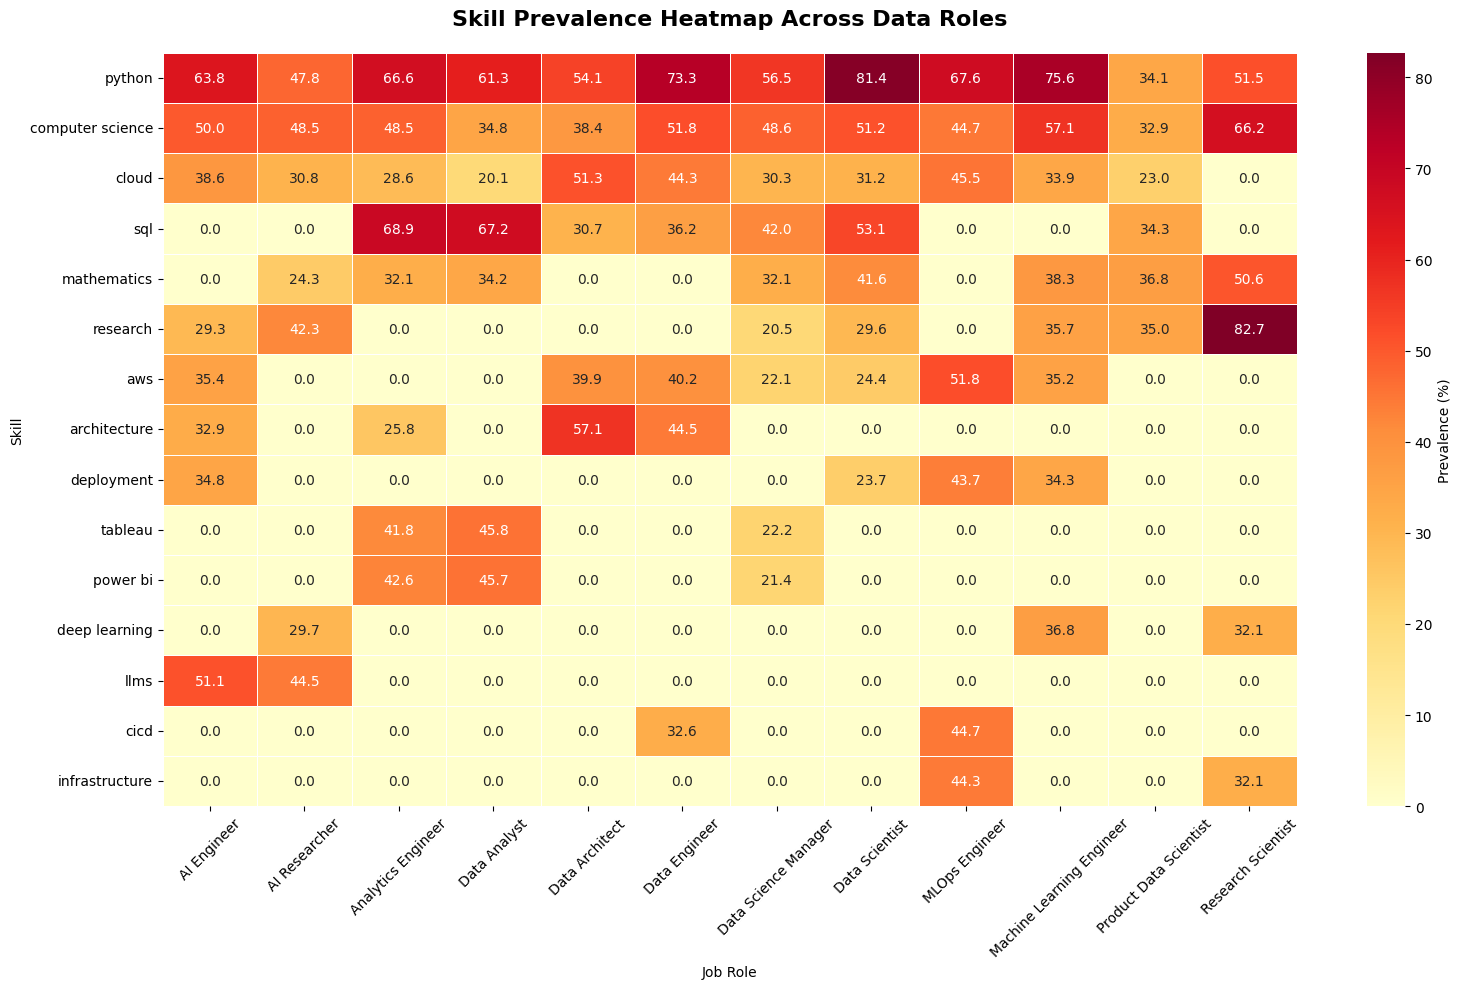


💡 Key Observations:
• Roles with distinct skill profiles are clearly visible
• Universal skills appear across multiple roles
• Role-specific specializations are evident


In [10]:
# Compare skill profiles across roles
print("🔄 ROLE SKILL PROFILE COMPARISON")
print("="*45)

role_comparison = analyzer.compare_role_skill_profiles(pivot_df)

# Create heatmap for role comparison
plt.figure(figsize=(16, 10))

# Select top skills for visualization
top_skills_comparison = role_comparison.mean(axis=1).nlargest(15).index
comparison_vis = role_comparison.loc[top_skills_comparison]

# Create heatmap
sns.heatmap(comparison_vis, annot=True, fmt='.1f', cmap='YlOrRd', 
            linewidths=0.5, cbar_kws={'label': 'Prevalence (%)'})
plt.title('Skill Prevalence Heatmap Across Data Roles', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Job Role')
plt.ylabel('Skill')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n💡 Key Observations:")
print("• Roles with distinct skill profiles are clearly visible")
print("• Universal skills appear across multiple roles")
print("• Role-specific specializations are evident")

## 5. Trend Analysis


In [11]:

trend_results = analyzer.analyze_skill_trends_full(pivot_df, min_prevalence=1.0, min_months=6)

if trend_results.empty:
    print("❌ No trend results generated - check your data")
else:
    print(f"✅ Generated trend analysis for {len(trend_results)} skills")
    
    # Display summary
    category_counts = trend_results['trend_category'].value_counts()
    print(f"\n📊 Trend Category Distribution:")
    for category, count in category_counts.items():
        percentage = (count / len(trend_results)) * 100
        print(f"   • {category}: {count} skills ({percentage:.1f}%)")





✅ Generated trend analysis for 177 skills

📊 Trend Category Distribution:
   • Stable: 98 skills (55.4%)
   • Stabilizing: 33 skills (18.6%)
   • Declining: 19 skills (10.7%)
   • Growing: 17 skills (9.6%)
   • Reviving: 5 skills (2.8%)
   • Rapidly Declining: 3 skills (1.7%)
   • Accelerating: 1 skills (0.6%)
   • Mature: 1 skills (0.6%)


### 5.1 TREND CATEGORIES DISTRIBUTION 



📊 VISUALIZATION 1: Trend Categories Distribution


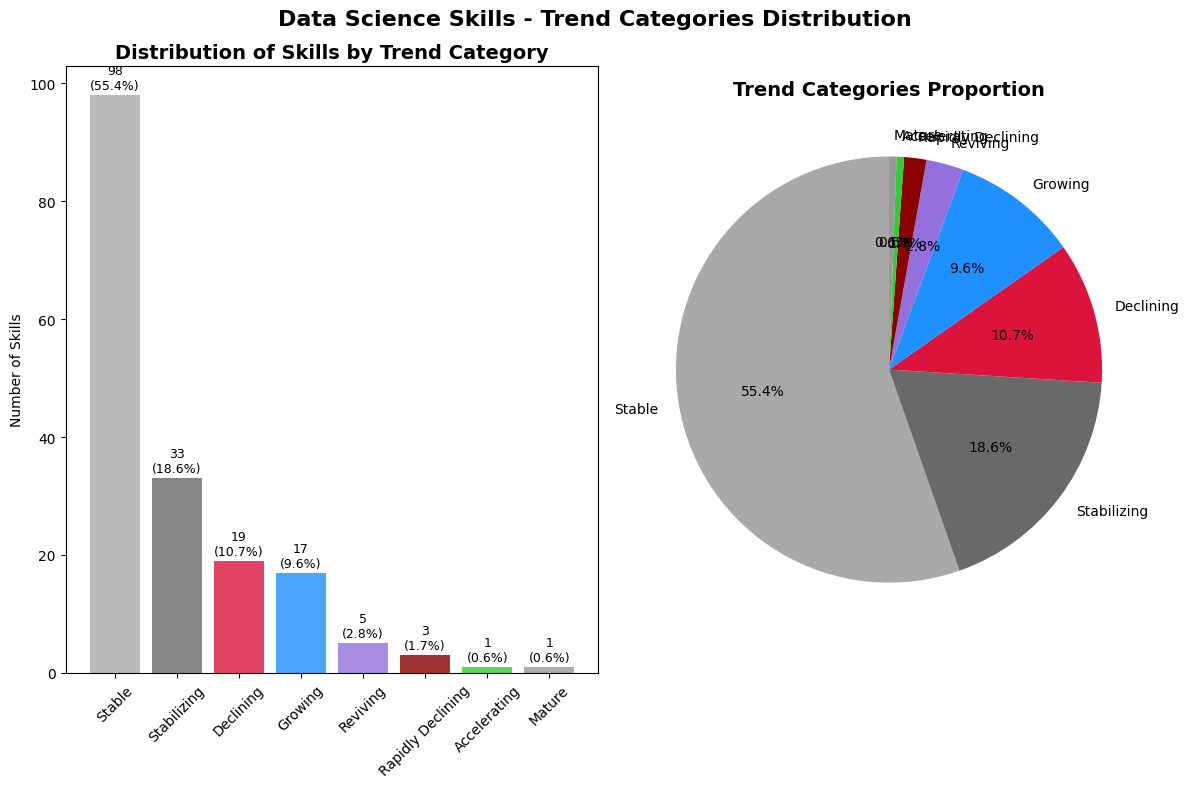

In [12]:
print("\n" + "="*50)
print("📊 VISUALIZATION 1: Trend Categories Distribution")
print("="*50)

fig1 = analyzer.plot_trend_categories_distribution(trend_results)
plt.suptitle('Data Science Skills - Trend Categories Distribution', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

### 5.2 Declining Skills Analysis


🔥 TOP EMERGING SKILLS:
   No emerging skills found

📈 VISUALIZATION 2: Emerging vs Declining Skills


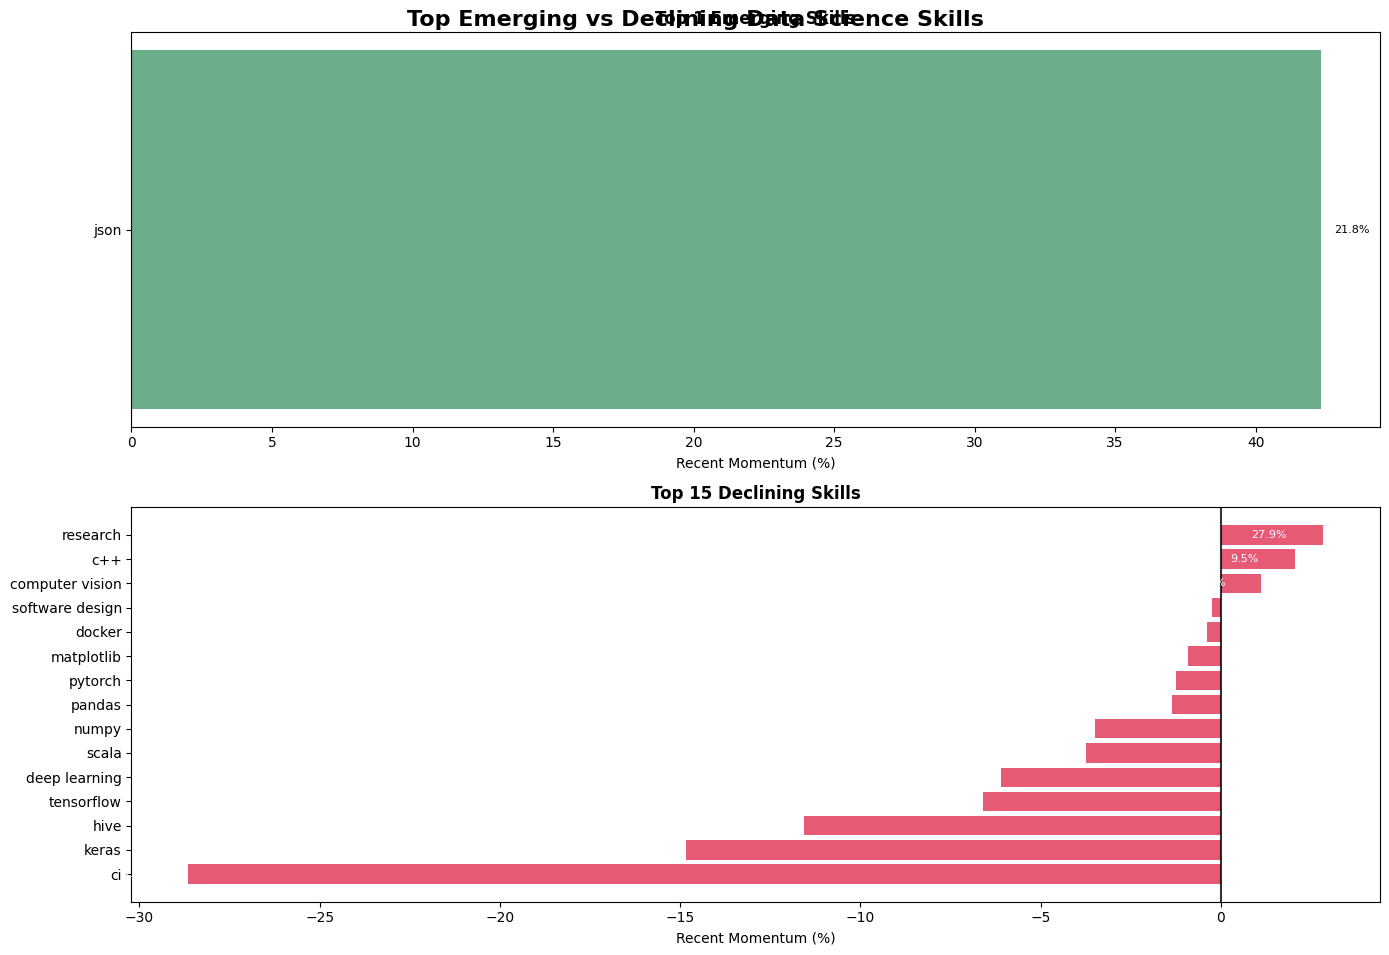


🎯 CAREER INSIGHTS:
   • 1 emerging skills → Focus on learning these
   • 22 declining skills → Avoid investing time in these

📊 VISUALIZATION 3: Trend Scatter Matrix


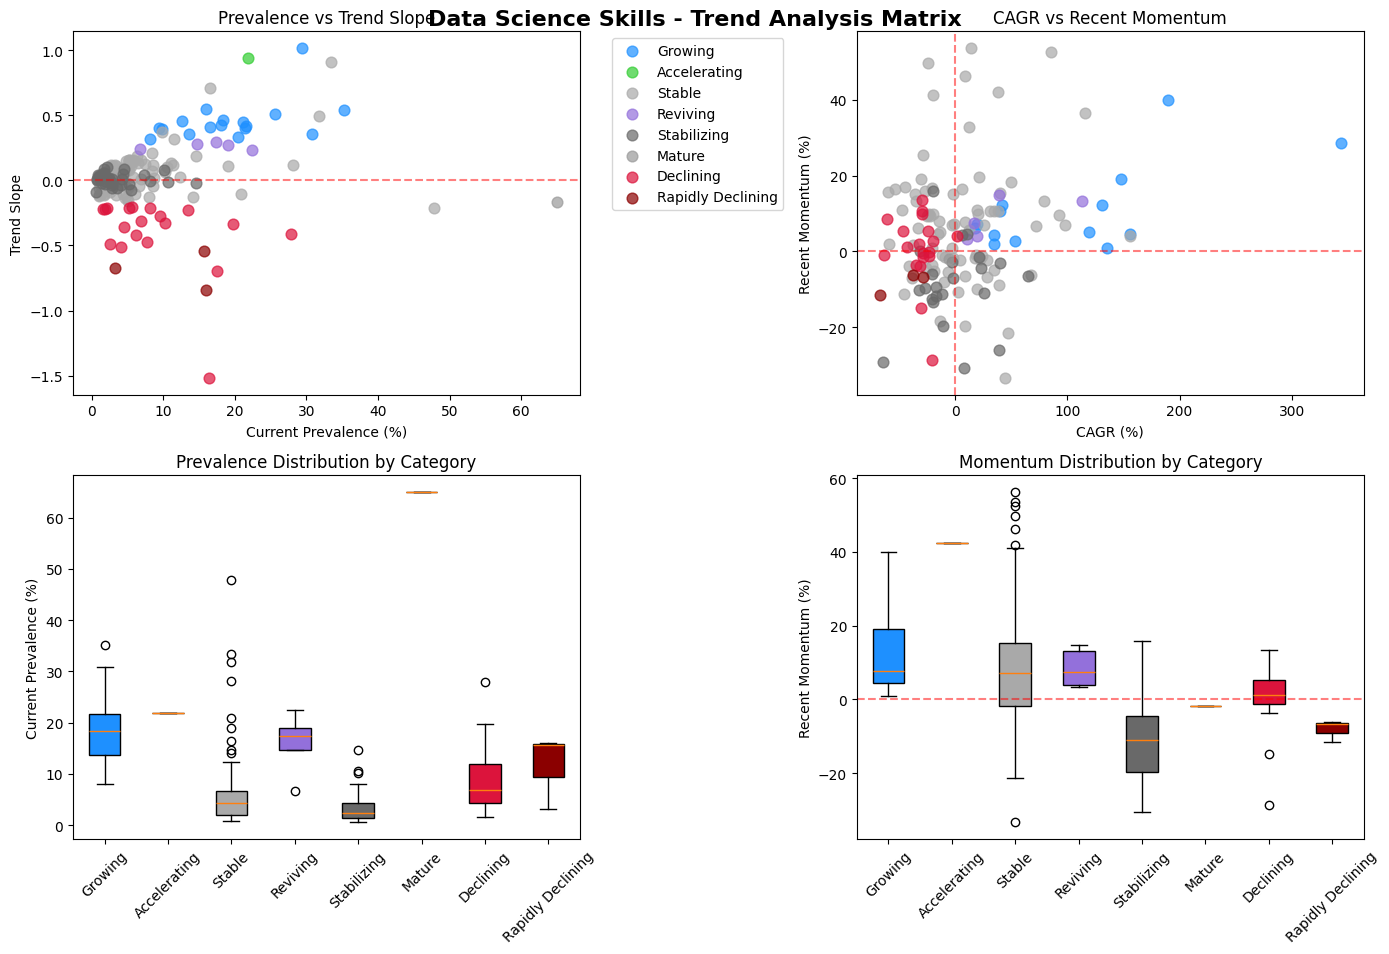


💡 INTERPRETATION GUIDE:
   • Prevalence vs Slope: Top-right = high-demand growing skills
   • CAGR vs Momentum: Consistent growth patterns
   • Look for skills with high prevalence + positive slope

🔗 VISUALIZATION 4: Correlation Heatmap

📡 VISUALIZATION 5: Trend Radar Chart


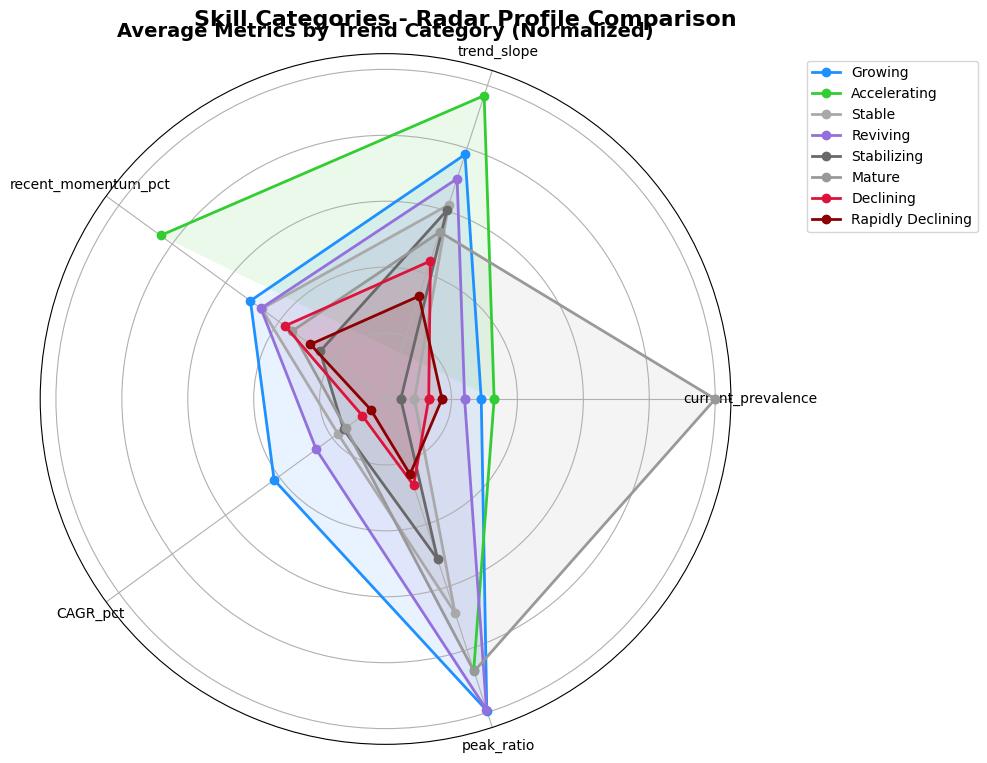


⏰ VISUALIZATION 6: Skill Timelines
   No emerging skills for timeline


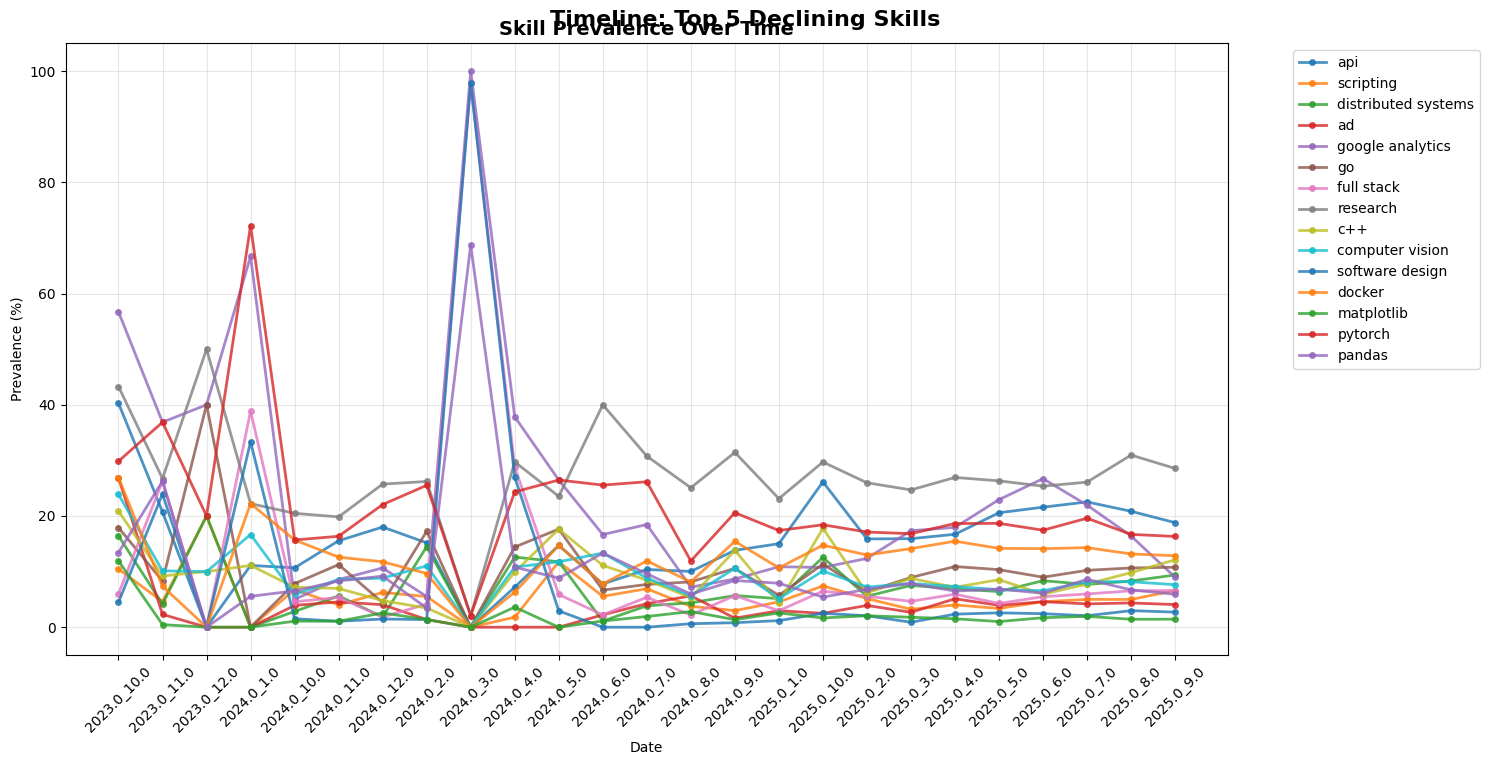

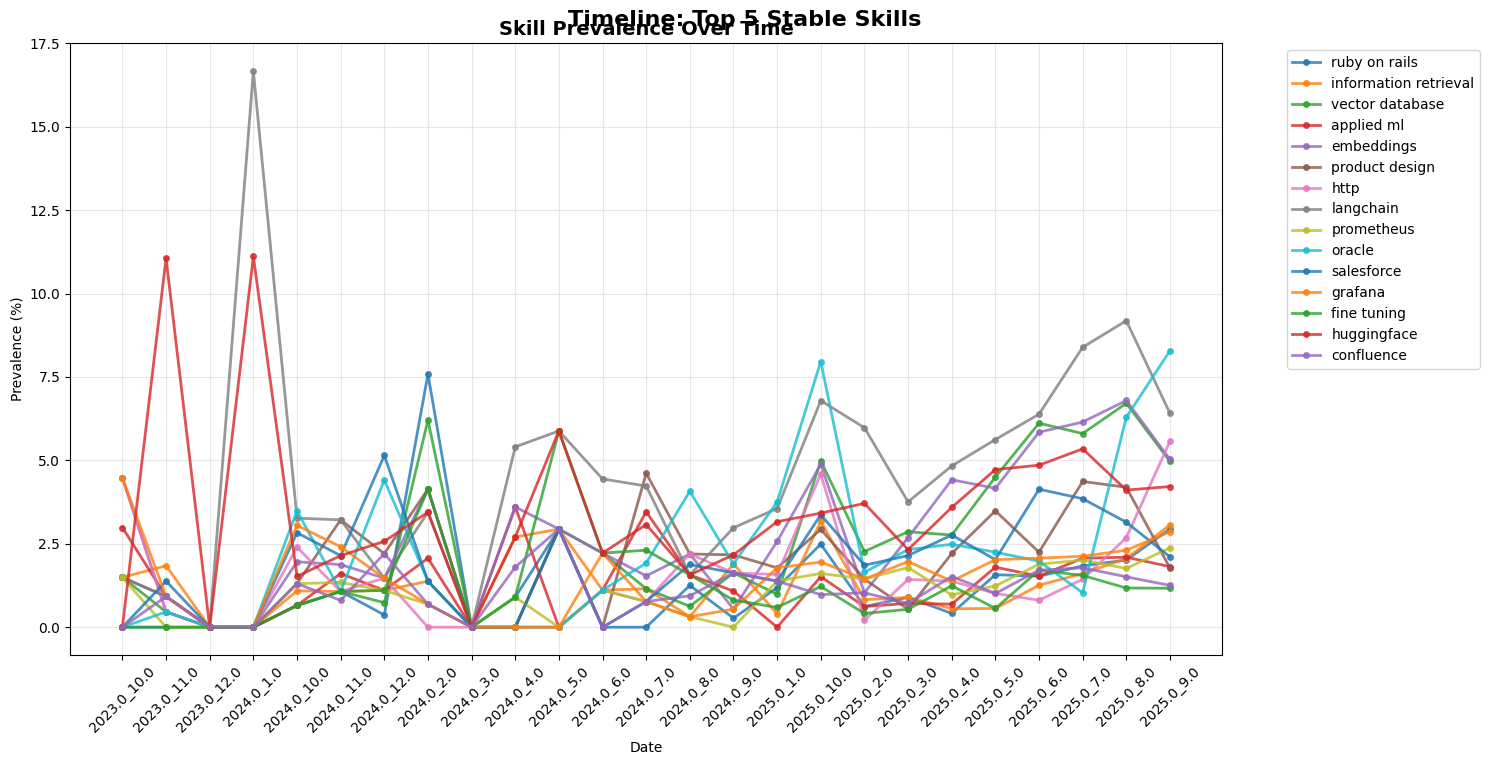


📋 TREND SUMMARY AND INSIGHTS

📈 TREND CATEGORY SUMMARY:
                   skill_count  current_prevalence_mean  \
trend_category                                            
Stable                      98                    6.230   
Stabilizing                 33                    3.558   
Declining                   19                    9.017   
Growing                     17                   19.290   
Reviving                     5                   16.033   
Rapidly Declining            3                   11.618   
Accelerating                 1                   21.806   
Mature                       1                   65.026   

                   current_prevalence_std  trend_slope_mean  trend_slope_std  \
trend_category                                                                 
Stable                              7.372             0.052            0.158   
Stabilizing                         3.271             0.008            0.048   
Declining                       

In [13]:
# Display top skills by category
print("\n🔥 TOP EMERGING SKILLS:")
emerging_skills = analyzer.get_top_skills_by_category(trend_results, 'Emerging', 10)
if not emerging_skills.empty:
    for _, row in emerging_skills.iterrows():
        print(f"   • {row['skill']}: {row['recent_momentum_pct']:+.1f}% momentum, {row['current_prevalence']:.1f}% prevalence")
else:
    print("   No emerging skills found")

# ===== VISUALIZATION 2: EMERGING VS DECLINING SKILLS =====
print("\n" + "="*50)
print("📈 VISUALIZATION 2: Emerging vs Declining Skills")
print("="*50)

fig2 = analyzer.plot_emerging_vs_declining_skills(trend_results, top_n=15)
plt.suptitle('Top Emerging vs Declining Data Science Skills', fontsize=16, fontweight='bold', y=0.95)
plt.tight_layout()
plt.show()

# Career insights
print("\n🎯 CAREER INSIGHTS:")
emerging_count = trend_results['is_emerging'].sum()
declining_count = trend_results['is_declining'].sum()
print(f"   • {emerging_count} emerging skills → Focus on learning these")
print(f"   • {declining_count} declining skills → Avoid investing time in these")

# ===== VISUALIZATION 3: TREND SCATTER MATRIX =====
print("\n" + "="*50)
print("📊 VISUALIZATION 3: Trend Scatter Matrix")
print("="*50)

fig3 = analyzer.plot_trend_scatter_matrix(trend_results)
plt.suptitle('Data Science Skills - Trend Analysis Matrix', fontsize=16, fontweight='bold', y=0.95)
plt.tight_layout()
plt.show()

print("\n💡 INTERPRETATION GUIDE:")
print("   • Prevalence vs Slope: Top-right = high-demand growing skills")
print("   • CAGR vs Momentum: Consistent growth patterns")
print("   • Look for skills with high prevalence + positive slope")

# ===== VISUALIZATION 4: CORRELATION HEATMAP =====
print("\n" + "="*50)
print("🔗 VISUALIZATION 4: Correlation Heatmap")
print("="*50)

#fig4 = analyzer.plot_heatmap_correlation(trend_results)
#plt.suptitle('Skill Metrics Correlation Matrix', fontsize=16, fontweight='bold', y=0.95)
#plt.tight_layout()
#plt.show()

# ===== VISUALIZATION 5: TREND RADAR CHART =====
print("\n" + "="*50)
print("📡 VISUALIZATION 5: Trend Radar Chart")
print("="*50)

fig5 = analyzer.plot_trend_radar_chart(trend_results)
if fig5:
    plt.suptitle('Skill Categories - Radar Profile Comparison', fontsize=16, fontweight='bold', y=0.95)
    plt.tight_layout()
    plt.show()
else:
    print("   Not enough data for radar chart")

# ===== VISUALIZATION 6: SKILL TIMELINES =====
print("\n" + "="*50)
print("⏰ VISUALIZATION 6: Skill Timelines")
print("="*50)

# Get top 5 emerging skills for timeline
top_emerging_skills = analyzer.get_top_skills_by_category(trend_results, 'Emerging', 15)
if not top_emerging_skills.empty:
    skill_names = top_emerging_skills['skill'].tolist()
    fig6 = analyzer.plot_skill_trend_timeline(pivot_df, skill_names)
    plt.suptitle('Timeline: Top 5 Emerging Skills', fontsize=16, fontweight='bold', y=0.95)
    plt.tight_layout()
    plt.show()
else:
    print("   No emerging skills for timeline")


top_emerging_skills = analyzer.get_top_skills_by_category(trend_results, 'Declining', 15)
if not top_emerging_skills.empty:
    skill_names = top_emerging_skills['skill'].tolist()
    fig6 = analyzer.plot_skill_trend_timeline(pivot_df, skill_names)
    plt.suptitle('Timeline: Top 5 Declining Skills', fontsize=16, fontweight='bold', y=0.95)
    plt.tight_layout()
    plt.show()
else:
    print("   No emerging skills for timeline")
top_emerging_skills = analyzer.get_top_skills_by_category(trend_results, 'Stable', 15)
if not top_emerging_skills.empty:
    skill_names = top_emerging_skills['skill'].tolist()
    fig6 = analyzer.plot_skill_trend_timeline(pivot_df, skill_names)
    plt.suptitle('Timeline: Top 5 Stable Skills', fontsize=16, fontweight='bold', y=0.95)
    plt.tight_layout()
    plt.show()
else:
    print("   No emerging skills for timeline")
# ===== TREND SUMMARY AND INSIGHTS =====
print("\n" + "="*50)
print("📋 TREND SUMMARY AND INSIGHTS")
print("="*50)

# Get trend summary
summary = analyzer.get_trend_summary(trend_results)
if not summary.empty:
    print("\n📈 TREND CATEGORY SUMMARY:")
    print(summary)

# Generate actionable insights
print("\n🎯 ACTIONABLE INSIGHTS FOR DATA SCIENCE CAREERS:")

# Top emerging skills with good prevalence
high_potential_emerging = trend_results[
    (trend_results['is_emerging']) & 
    (trend_results['current_prevalence'] > 5)
].nlargest(5, 'recent_momentum_pct')

if not high_potential_emerging.empty:
    print(f"\n🔥 HIGH-POTENTIAL EMERGING SKILLS (learn now):")
    for _, skill in high_potential_emerging.iterrows():
        print(f"   • {skill['skill']}: {skill['recent_momentum_pct']:+.1f}% momentum, {skill['current_prevalence']:.1f}% prevalence")

# Established growing skills
established_growing = trend_results[
    (trend_results['is_growing']) & 
    (trend_results['current_prevalence'] > 20)
].nlargest(5, 'current_prevalence')

if not established_growing.empty:
    print(f"\n💼 ESTABLISHED GROWING SKILLS (solid investment):")
    for _, skill in established_growing.iterrows():
        print(f"   • {skill['skill']}: {skill['current_prevalence']:.1f}% prevalence, {skill['trend_slope']:.3f} slope")

# Declining skills to avoid
declining_to_avoid = trend_results[
    (trend_results['is_declining']) & 
    (trend_results['current_prevalence'] > 10)  # Still somewhat popular but declining
].nsmallest(5, 'recent_momentum_pct')

if not declining_to_avoid.empty:
    print(f"\n⚠️  DECLINING SKILLS (avoid investment):")
    for _, skill in declining_to_avoid.iterrows():
        print(f"   • {skill['skill']}: {skill['recent_momentum_pct']:+.1f}% momentum, {skill['current_prevalence']:.1f}% prevalence")





## 6. Skill Ecosystem Analysis
### 6.1 Skill Combinations and Clusters

INFO:src.analyze_jobs:🔗 Ultra-fast Skill Combination Prevalence Analysis...
INFO:src.analyze_jobs:🔗 Fast skill combination analysis...


🔗 SKILL COMBINATIONS AND NATURAL CLUSTERS


Counting combinations: 100%|██████████| 17954/17954 [00:01<00:00, 16593.51it/s]
INFO:src.analyze_jobs:📊 Pre-computing helper data...
Pre-computing skill job sets: 100%|██████████| 20/20 [00:00<00:00, 21.37it/s]
INFO:src.analyze_jobs:🎯 Pre-computing role skill rankings...
Processing combinations: 100%|██████████| 30/30 [00:00<00:00, 40.72it/s]


🤝 TOP SKILL COMBINATIONS
------------------------------


,skill_1,skill_2,prevalence,combination_type,learning_synergy
0,computer science,python,24.33%,Cross-Domain: Other + Programming,Very High Synergy
1,python,sql,19.45%,Same Domain: Programming,High Synergy
2,mathematics,python,15.71%,Cross-Domain: Other + Programming,High Synergy
3,cloud,python,15.57%,Cross-Domain: Other + Programming,High Synergy
4,computer science,mathematics,13.78%,Same Domain: Other,High Synergy
5,python,research,12.80%,Cross-Domain: Programming + Other,Medium Synergy
6,json,mathematics,12.71%,Same Domain: Other,Very High Synergy
7,aws,python,12.55%,Cross-Domain: Cloud + Programming,High Synergy
8,computer science,research,11.44%,Same Domain: Other,Medium Synergy
9,computer science,sql,11.12%,Cross-Domain: Other + Programming,Medium Synergy


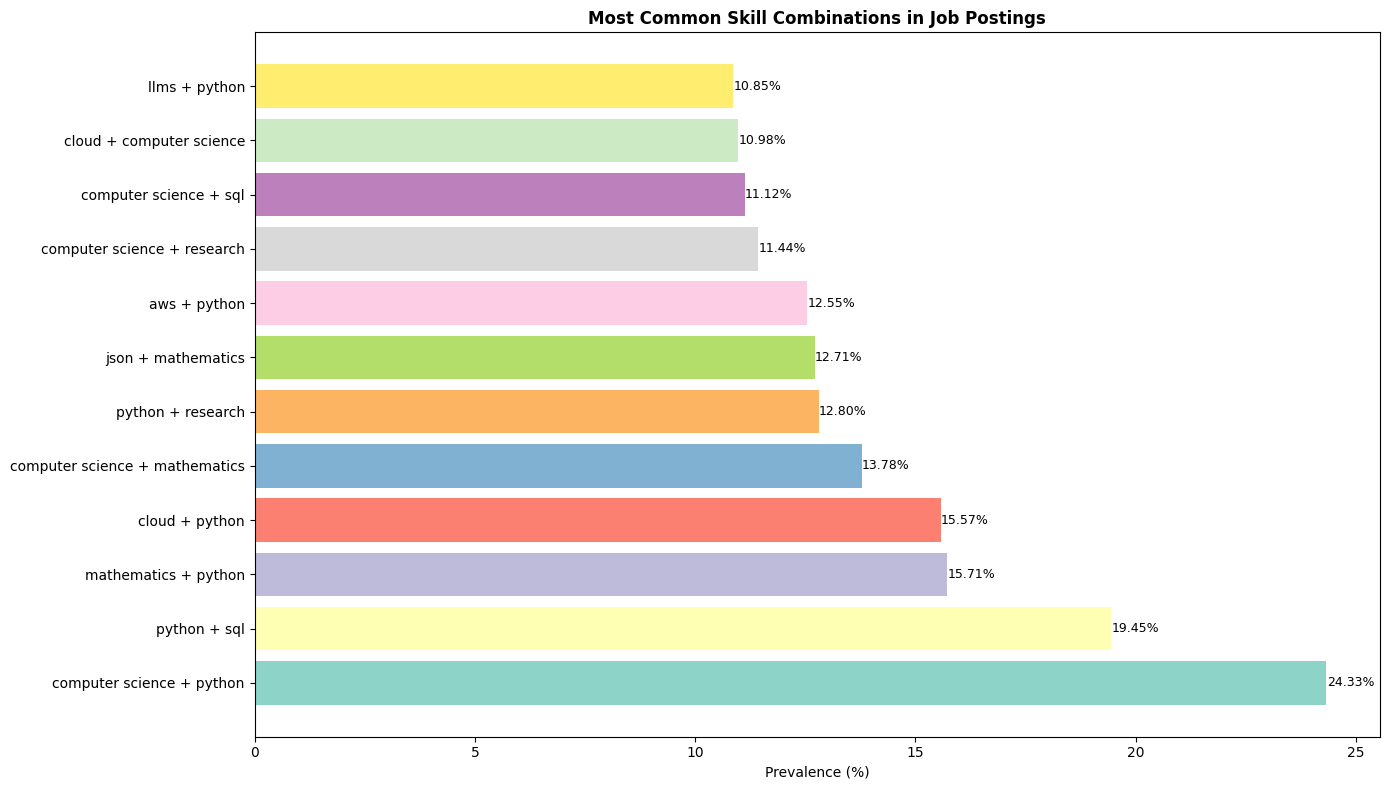

In [14]:
# Analyze skill combinations and natural clusters
print("🔗 SKILL COMBINATIONS AND NATURAL CLUSTERS")
print("="*55)

# Analyze common skill combinations
skill_combinations = analyzer.analyze_skill_combination_prevalence(pivot_df, top_n=15)

if not skill_combinations.empty:
    print("\n🤝 TOP SKILL COMBINATIONS")
    print("-" * 30)
    
    # Display combination table
    combo_display = skill_combinations[['skill_1', 'skill_2', 'prevalence', 'combination_type', 'learning_synergy']]
    display(combo_display.head(10).style.background_gradient(cmap='Purples', subset=['prevalence'])
           .format({'prevalence': '{:.2f}%'}))
    
    # Visualize combinations
    plt.figure(figsize=(14, 8))
    top_combos = skill_combinations.head(12)
    
    # Create combination labels
    combo_labels = [f"{row['skill_1']} + {row['skill_2']}" for _, row in top_combos.iterrows()]
    
    plt.barh(combo_labels, top_combos['prevalence'], 
             color=plt.cm.Set3(np.linspace(0, 1, len(top_combos))))
    plt.xlabel('Prevalence (%)')
    plt.title('Most Common Skill Combinations in Job Postings', fontweight='bold')
    
    for i, v in enumerate(top_combos['prevalence']):
        plt.text(v + 0.01, i, f'{v:.2f}%', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()

### 6.2 Natural Skill Clusters

INFO:src.analyze_jobs:🎯 Fast Natural Skill Clusters Identification...



🎯 NATURAL SKILL CLUSTERS
------------------------------


Building clusters: 100%|██████████| 30/30 [00:00<00:00, 547.08it/s]


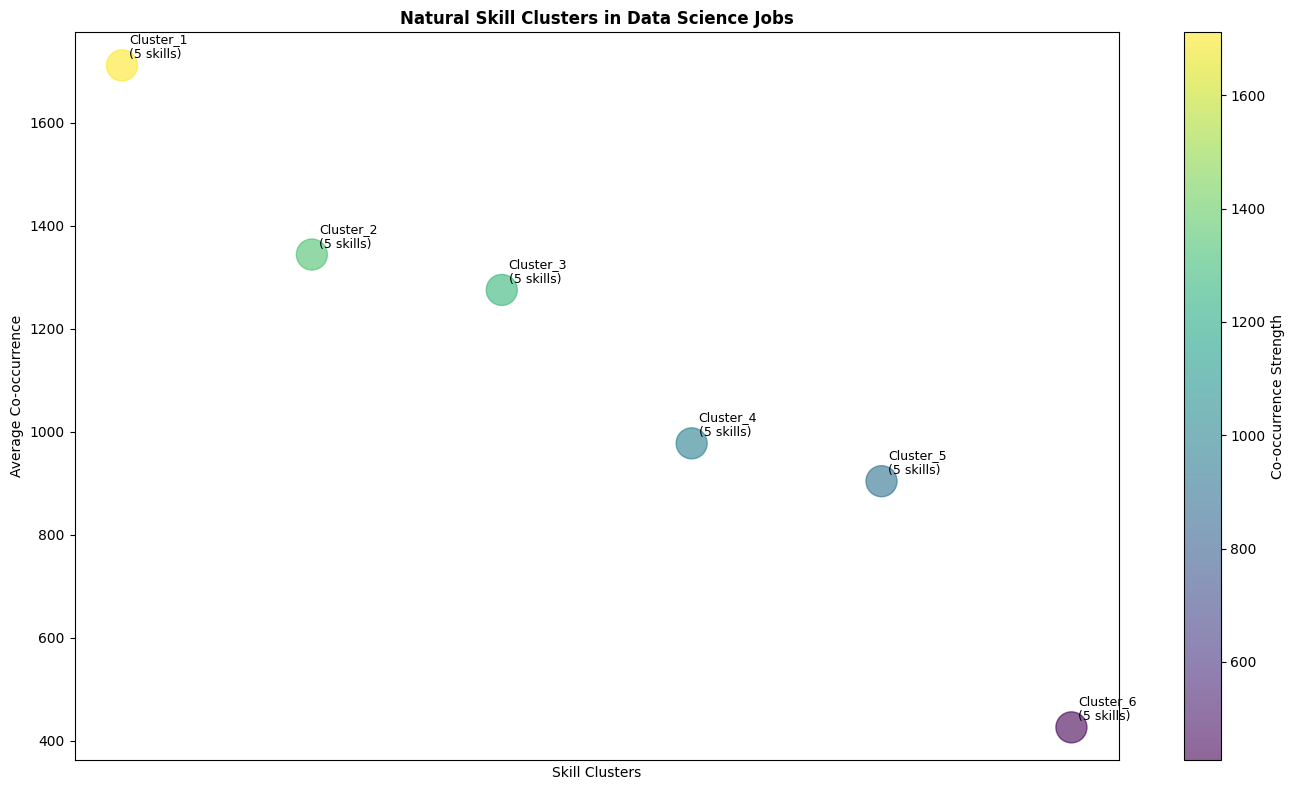


🔍 Cluster Details:

   Cluster_1:
      Core skill: deep learning
      Skills: deep learning, python, computer science, pytorch
      Avg co-occurrence: 1711.0

   Cluster_2:
      Core skill: agile
      Skills: agile, cloud, architecture, aws
      Avg co-occurrence: 1344.0

   Cluster_3:
      Core skill: cicd
      Skills: cicd, deployment, api, gcp
      Avg co-occurrence: 1275.2

   Cluster_4:
      Core skill: nlp
      Skills: nlp, llms, tensorflow, mathematics
      Avg co-occurrence: 977.5

   Cluster_5:
      Core skill: testing
      Skills: testing, infrastructure, automation, security
      Avg co-occurrence: 904.0

   Cluster_6:
      Core skill: transformation
      Skills: transformation, ios, google analytics, java
      Avg co-occurrence: 426.2


In [15]:
# Identify natural skill clusters
print("\n🎯 NATURAL SKILL CLUSTERS")
print("-" * 30)

skill_clusters = analyzer.identify_natural_skill_clusters(pivot_df)

if skill_clusters:
    # Visualize clusters
    fig, ax = plt.subplots(figsize=(14, 8))
    
    cluster_names = list(skill_clusters.keys())
    cluster_sizes = [len(cluster['skills']) for cluster in skill_clusters.values()]
    cluster_co_occurrence = [cluster['avg_co_occurrence'] for cluster in skill_clusters.values()]
    
    # Create bubble chart
    scatter = ax.scatter(range(len(cluster_names)), cluster_co_occurrence, 
                        s=[size*100 for size in cluster_sizes], alpha=0.6, 
                        c=cluster_co_occurrence, cmap='viridis')
    
    # Add labels
    for i, (name, size) in enumerate(zip(cluster_names, cluster_sizes)):
        ax.annotate(f"{name}\n({size} skills)", 
                   (i, cluster_co_occurrence[i]), 
                   xytext=(5, 5), textcoords='offset points',
                   fontsize=9, ha='left')
    
    ax.set_xlabel('Skill Clusters')
    ax.set_ylabel('Average Co-occurrence')
    ax.set_title('Natural Skill Clusters in Data Science Jobs', fontweight='bold')
    plt.colorbar(scatter, label='Co-occurrence Strength')
    plt.xticks([])
    plt.tight_layout()
    plt.show()
    
    # Print cluster details
    print("\n🔍 Cluster Details:")
    for cluster_name, cluster_data in list(skill_clusters.items())[:6]:
        print(f"\n   {cluster_name}:")
        print(f"      Core skill: {cluster_data['core_skill']}")
        print(f"      Skills: {', '.join(cluster_data['skills'][:4])}")
        print(f"      Avg co-occurrence: {cluster_data['avg_co_occurrence']:.1f}")

## 7. Regional and Company Analysis
### 7.1 Regional Skill Demand 

🌍 REGIONAL SKILL DEMAND VARIATIONS


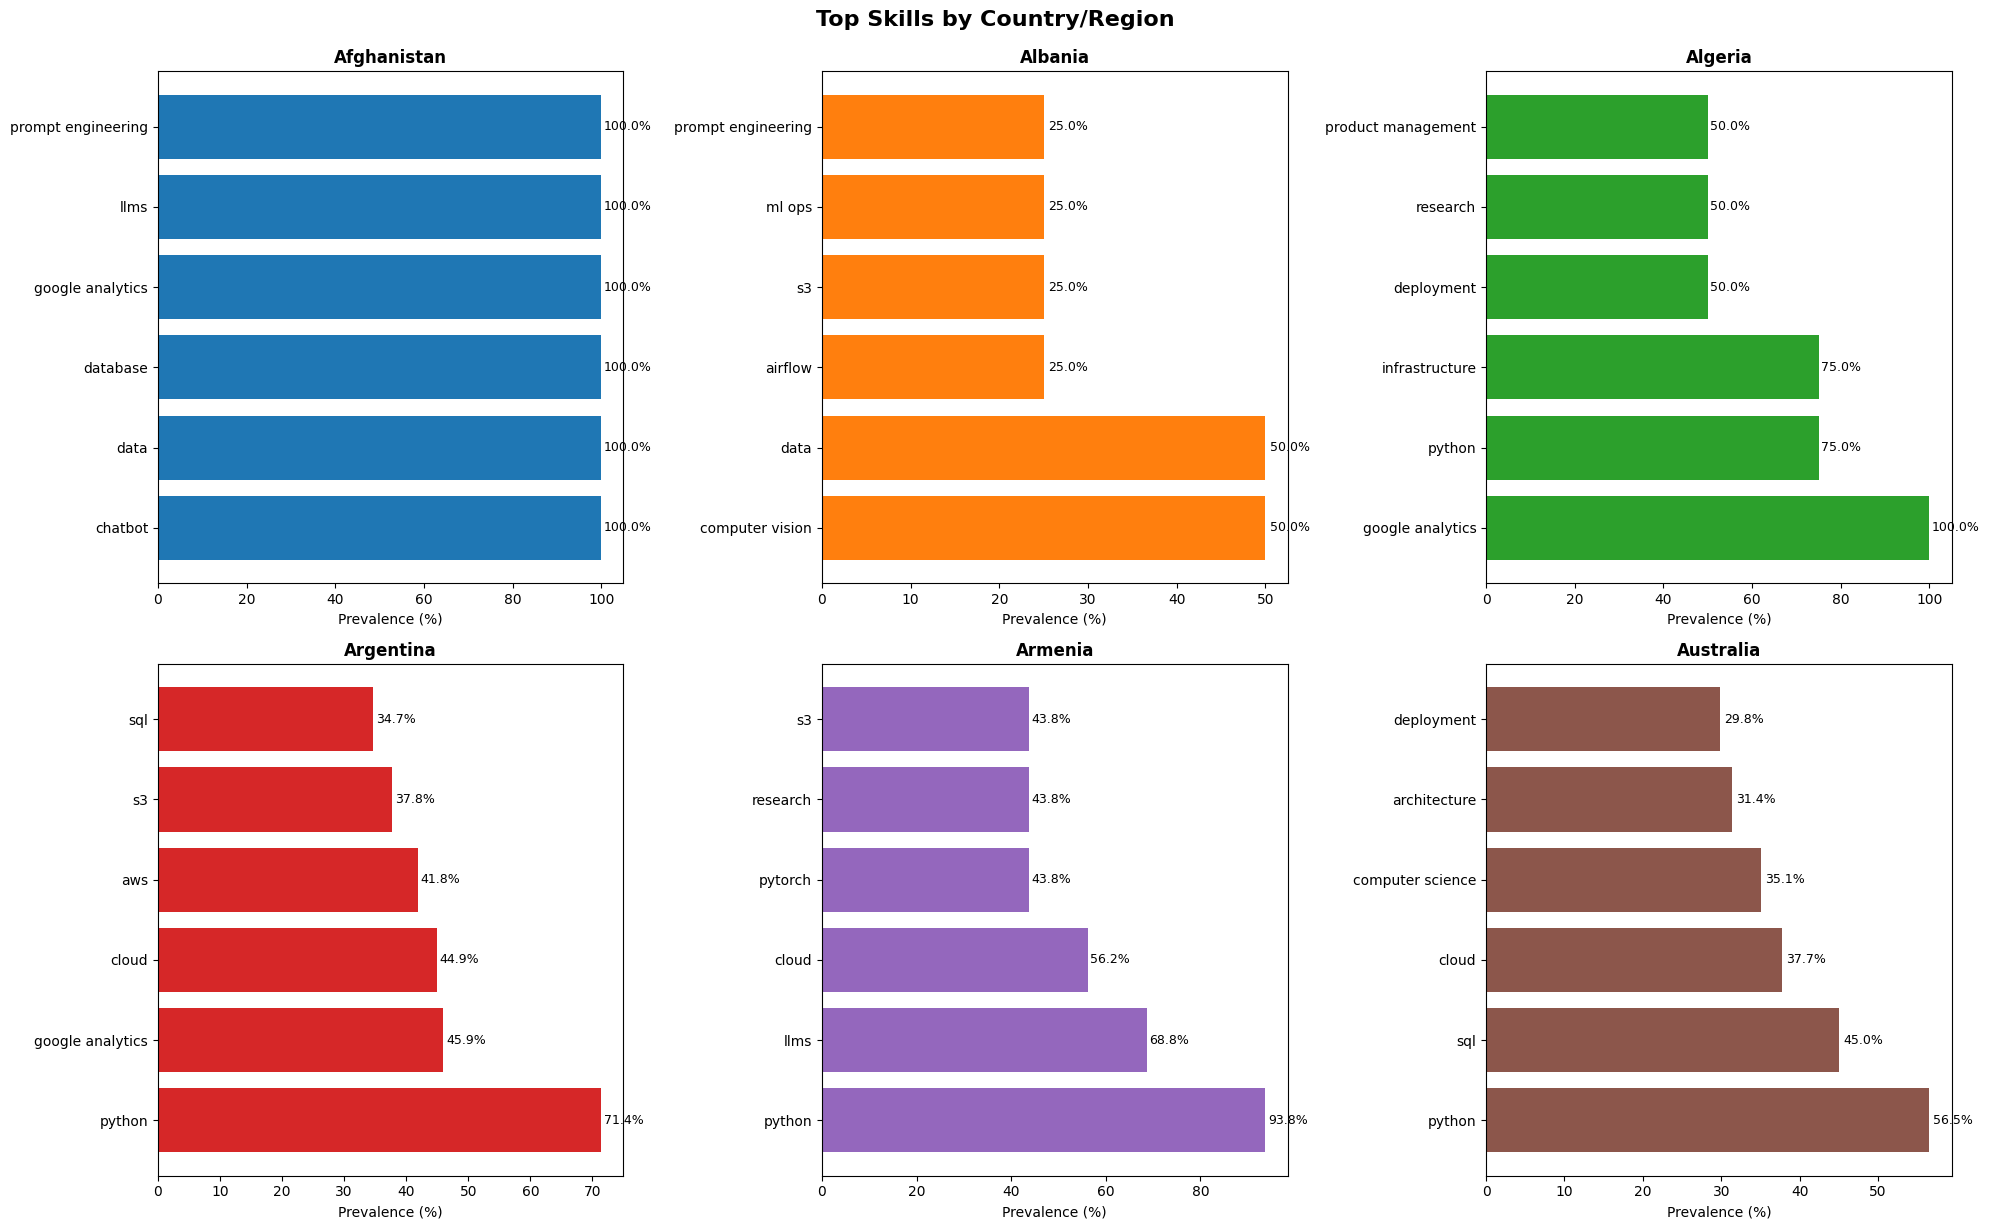

💡 Regional Insights:
   • Afghanistan: chatbot (100.0%)
   • Albania: computer vision (50.0%)
   • Algeria: google analytics (100.0%)


In [16]:
# Analyze regional variations in skill demand
print("🌍 REGIONAL SKILL DEMAND VARIATIONS")
print("="*45)

regional_skills = analyzer.analyze_regional_skill_demand(pivot_df, top_n=8)

if regional_skills:
    # Plot top countries
    top_countries = list(regional_skills.keys())[:6]
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.flatten()
    
    for idx, country in enumerate(top_countries):
        if idx < 6:
            ax = axes[idx]
            country_data = regional_skills[country].head(6)
            
            ax.barh(country_data['skill'], country_data['prevalence'], 
                   color=plt.cm.tab10(idx))
            ax.set_title(f'{country}', fontweight='bold', fontsize=12)
            ax.set_xlabel('Prevalence (%)')
            
            for i, v in enumerate(country_data['prevalence']):
                ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.suptitle('Top Skills by Country/Region', fontsize=16, fontweight='bold', y=1.02)
    plt.show()
    
    print("💡 Regional Insights:")
    for country in top_countries[:3]:
        top_skill = regional_skills[country].iloc[0]['skill']
        prevalence = regional_skills[country].iloc[0]['prevalence']
        print(f"   • {country}: {top_skill} ({prevalence:.1f}%)")